# Customer Intelligence System
## Classification, Ensemble Learning & Customer Segmentation

**Dataset:** [Unsupervised Learning on Country Data – Kaggle](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

**Techniques Used:**
- Clustering: K-Means, DBSCAN
- Dimensionality Reduction: PCA
- Classification & Ensemble Learning: Random Forest, XGBoost


## 1. Install Dependencies

In [40]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost -q

## 2. Import Libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, accuracy_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Dataset

The Country Data dataset contains socio-economic and health indicators for 167 countries,
including child mortality, income, GDP per capita, life expectancy, exports, imports,
inflation, fertility, and health expenditure.

**Loading options:** Kaggle path shown below. For Google Colab, replace with file upload.


In [42]:
import os

file_name = 'Country-data.csv'

try:
    # Attempt to load from the local directory first
    if os.path.exists(file_name):
        print(f"Loading '{file_name}' from local directory...")
        df = pd.read_csv(file_name)
    else:
        # If not found locally, download via kagglehub
        !pip install kagglehub
        import kagglehub
        dataset_handle = 'rohan0301/unsupervised-learning-on-country-data'
        print(f"\n'{file_name}' not found locally. Downloading from Kaggle...")
        download_path = kagglehub.dataset_download(dataset_handle)
        # Construct the full path and load
        csv_file_path = os.path.join(download_path, file_name)
        df = pd.read_csv(csv_file_path)
        print("Download and load successful.")

    print(f"Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")

except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")


'Country-data.csv' not found locally. Downloading from Kaggle...
Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Download and load successful.
Dimensions: 167 rows × 10 columns


## 4. Exploratory Data Analysis

In [43]:
print("=== Dataset Info ===")
df.info()
print("\n=== Descriptive Statistics ===")
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

=== Descriptive Statistics ===


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [44]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows: 0


**Observation – EDA:**
- The dataset has 167 rows and 10 columns (1 categorical: `country`, 9 numerical features).
- No missing values exist in the raw data; however, outliers are present in features like `gdpp` and `income`.
- Features span different scales (e.g., `child_mort` in single/double digits vs `gdpp` in tens of thousands),
  making standardization essential before clustering.


### 4.1 Correlation Heatmap

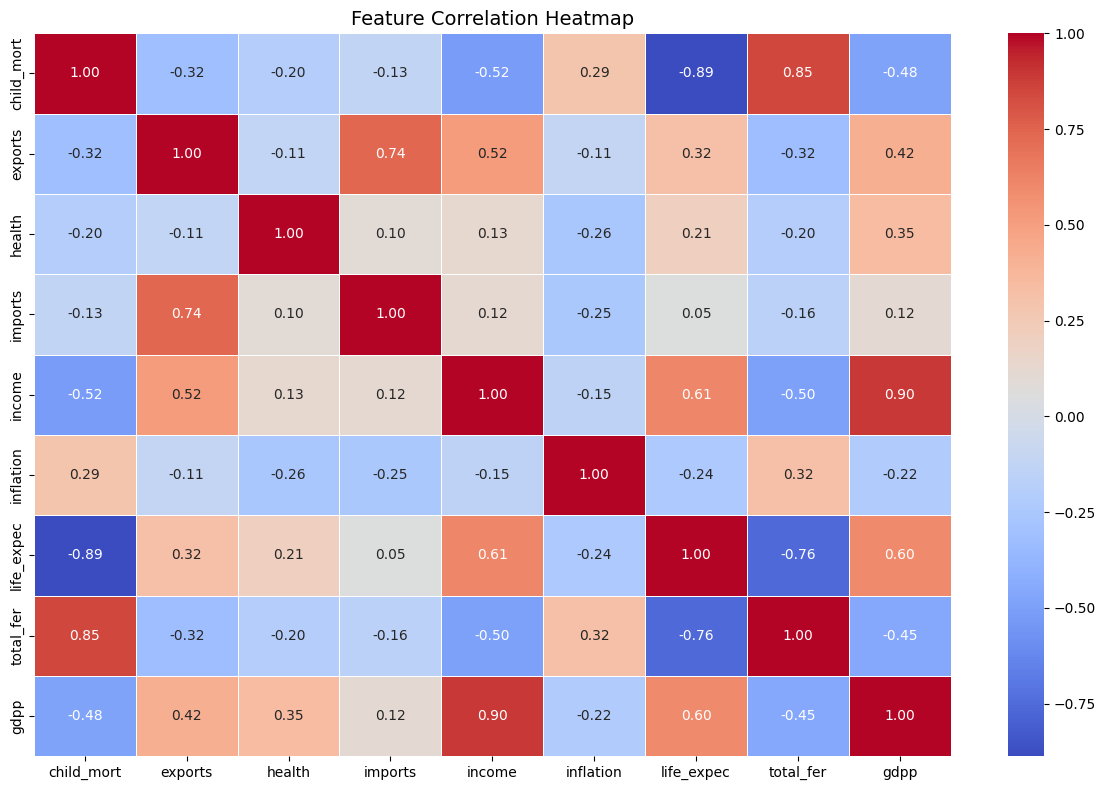

In [45]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

**Observation – Correlation:**
- `income` and `gdpp` are highly correlated (r ≈ 0.90), indicating that countries with higher GDP
  also tend to have higher per-capita income.
- `child_mort` is strongly negatively correlated with `life_expec` (r ≈ -0.89), confirming that
  countries with high child mortality have lower life expectancy.
- `health` spending shows a moderate positive correlation with `life_expec`, suggesting that
  greater healthcare investment is associated with longer lifespans.


### 4.2 Feature Distributions

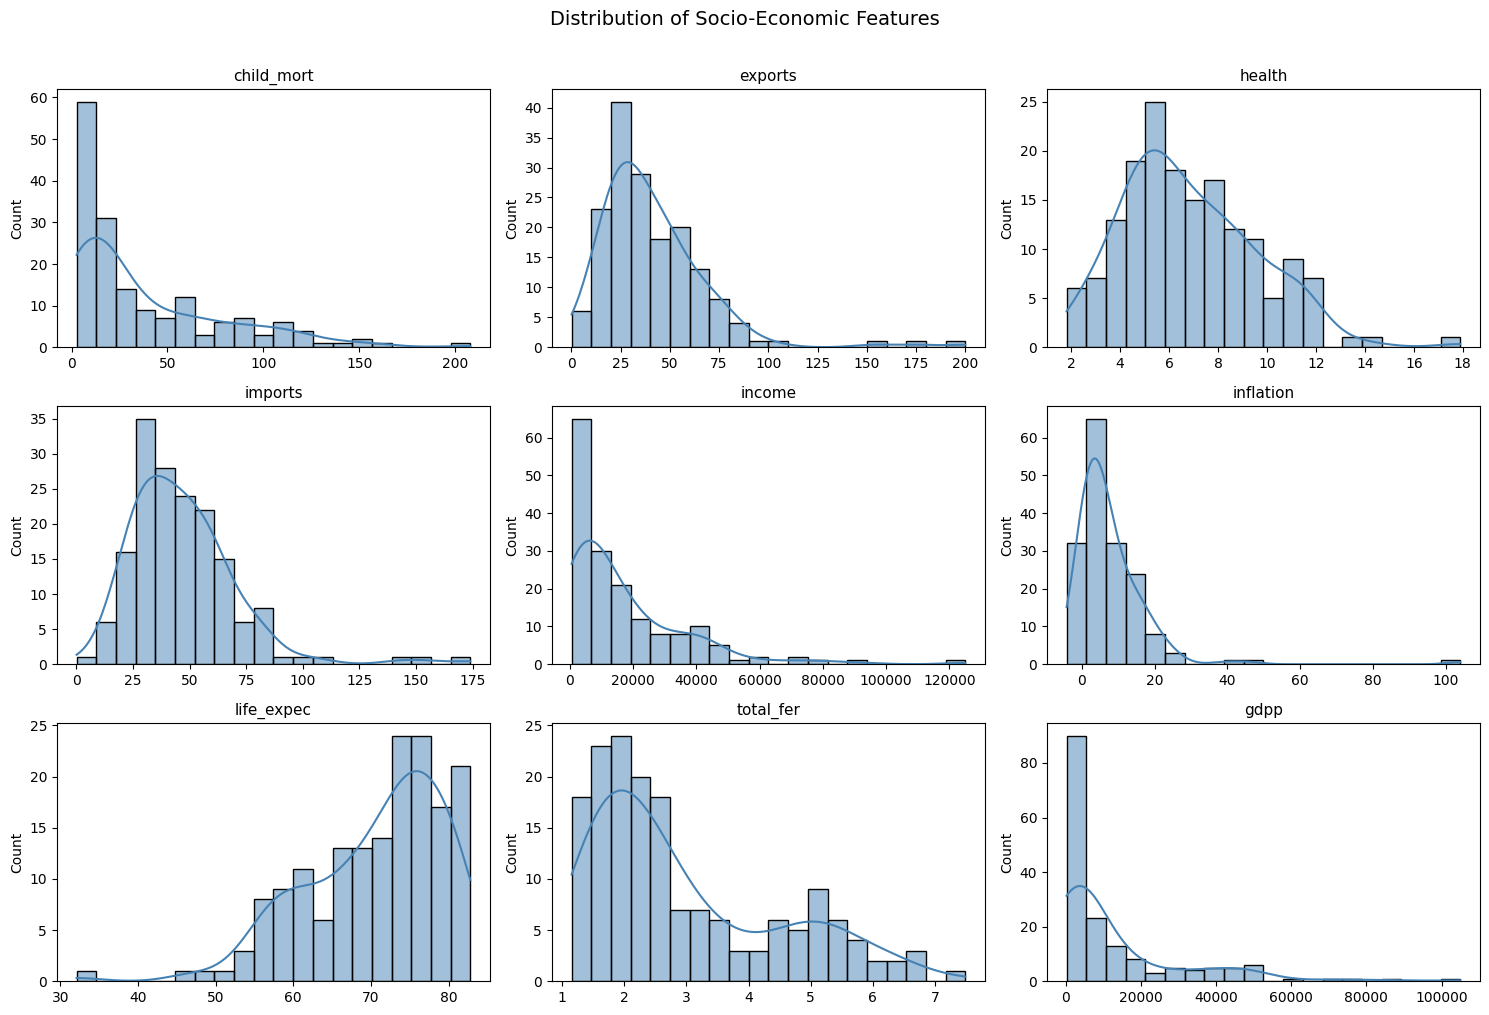

In [46]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
features_to_plot = ['child_mort', 'exports', 'health', 'imports',
                    'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

for ax, col in zip(axes.flatten(), features_to_plot):
    sns.histplot(df[col], bins=20, kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

plt.suptitle("Distribution of Socio-Economic Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation – Distributions:**
- `income` and `gdpp` are right-skewed, indicating that a few very wealthy countries
  pull the distribution to the right — most countries are clustered at lower income levels.
- `child_mort` is also right-skewed, with most countries having low rates but a tail of
  high-mortality nations.
- `life_expec` is approximately left-skewed, with most countries achieving 60–80 years.
- `inflation` shows extreme skew with some outlier values, suggesting a small number of
  countries experienced hyperinflation during the data period.


### 4.3 Income vs Life Expectancy

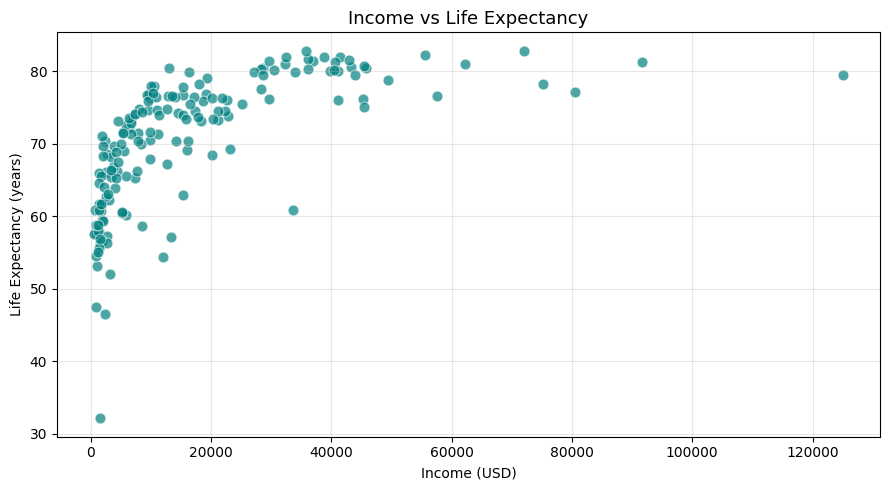

In [47]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='income', y='life_expec', data=df, color='teal', s=60, alpha=0.7)
plt.title("Income vs Life Expectancy", fontsize=13)
plt.xlabel("Income (USD)")
plt.ylabel("Life Expectancy (years)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation – Income vs Life Expectancy:**
- A clear positive relationship exists: higher income countries consistently show
  higher life expectancy.
- Countries with income below ~10,000 USD cluster in the 50–70 year range,
  while those above ~30,000 USD cluster near 75–85 years.
- A few mid-income outliers exist with unexpectedly low life expectancy,
  likely due to conflict or inequality.


## 5. Data Preprocessing

In [48]:
# Clean column names and remove duplicates
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)

# Ensure all feature columns are numeric
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Median imputation for any NaNs
df.fillna(df.median(numeric_only=True), inplace=True)

print("Remaining Missing Values:")
print(df.isnull().sum())
print("\nFinal Dataset Shape:", df.shape)

Remaining Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Final Dataset Shape: (167, 10)


**Observation – Preprocessing:**
- Column names were stripped of leading/trailing whitespace.
- No duplicate rows were found in this dataset.
- All numerical columns were confirmed as numeric types; any coercion-introduced NaNs
  were filled with column medians.
- The dataset is clean and ready for feature engineering and modeling.


### 5.1 Feature Separation and Standardization

In [49]:
country_names = df['country']
X = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature Matrix Shape:", X_scaled.shape)
print("Features Used:", list(X.columns))

Feature Matrix Shape: (167, 9)
Features Used: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


**Observation – Scaling:**
- `StandardScaler` transforms all features to zero mean and unit variance.
- This prevents high-magnitude features like `gdpp` (values ~40,000) from
  dominating low-magnitude features like `child_mort` (values ~5–200) in
  distance-based clustering algorithms.


## 6. K-Means Clustering

### 6.1 Elbow Method

In [50]:
inertias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={sil_scores[-1]:.4f}")

k=2: inertia=1050.21, silhouette=0.2874
k=3: inertia=831.42, silhouette=0.2833
k=4: inertia=700.52, silhouette=0.2960
k=5: inertia=620.16, silhouette=0.2993
k=6: inertia=558.47, silhouette=0.2287
k=7: inertia=495.81, silhouette=0.2477
k=8: inertia=457.59, silhouette=0.2388
k=9: inertia=427.80, silhouette=0.2073
k=10: inertia=403.23, silhouette=0.2022


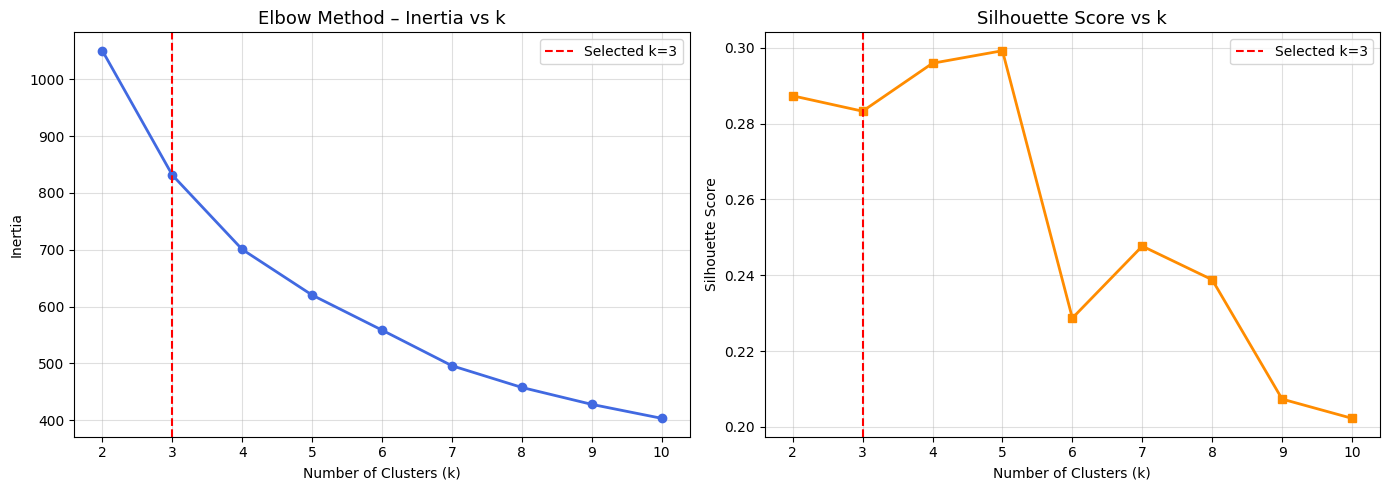

In [51]:
plt.figure(figsize=(14, 5))

# 1. Elbow Method Plot (1 row, 2 columns, 1st plot)
plt.subplot(1, 2, 1)
plt.plot(k_values, inertias, 'o-', color='royalblue', lw=2)
plt.axvline(3, color='red', ls='--', label='Selected k=3')
plt.title('Elbow Method – Inertia vs k', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.4)
plt.legend()

# 2. Silhouette Score Plot (1 row, 2 columns, 2nd plot)
plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, 's-', color='darkorange', lw=2)
plt.axvline(3, color='red', ls='--', label='Selected k=3')
plt.title('Silhouette Score vs k', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

**Observation – Elbow Method:**
- The inertia curve shows a clear elbow at **k = 3**, where the rate of decrease in
  inertia significantly slows down.
- The silhouette score peaks at k = 3 (≈ 0.28) and declines for higher k values,
  confirming that three clusters provide the best balance between cohesion and separation.
- k = 3 is selected as the optimal number of clusters for this dataset.


### 6.2 K-Means Model Training

In [52]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

print("Cluster Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())

sil = silhouette_score(X_scaled, kmeans_labels)
print(f"\nK-Means Silhouette Score: {sil:.4f}")

Cluster Distribution:
KMeans_Cluster
0    36
1    47
2    84
Name: count, dtype: int64

K-Means Silhouette Score: 0.2833


**Observation – K-Means Training:**
- The model assigns each of the 167 countries to one of three clusters.
- Silhouette Score ≈ 0.28 indicates moderate but acceptable cluster quality —
  typical for real-world socio-economic data where natural boundaries are gradual rather than sharp.
- The cluster sizes reflect the global distribution of development levels.


### 6.3 Cluster Profile Analysis

In [53]:
cluster_summary = df.groupby('KMeans_Cluster').mean(numeric_only=True).round(2)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


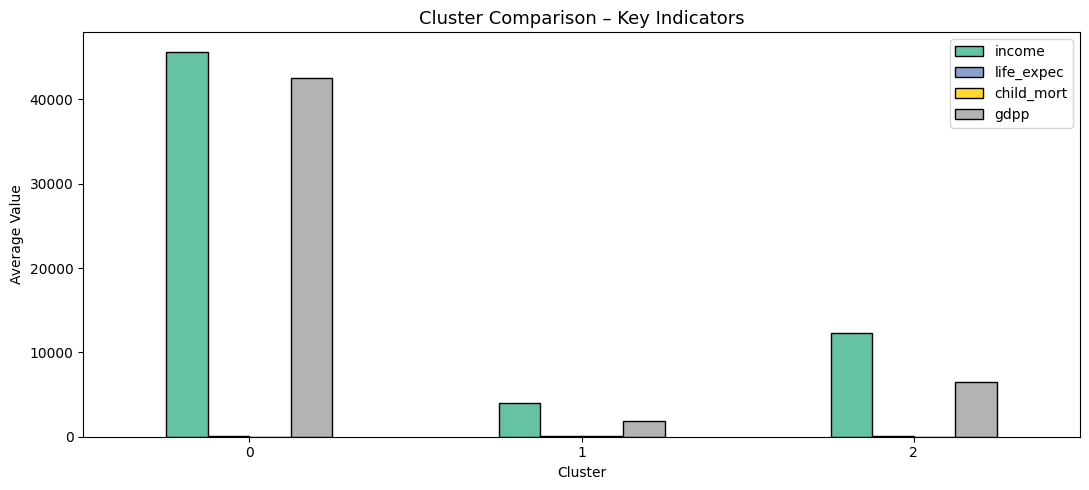

In [54]:
cluster_summary[['income', 'life_expec', 'child_mort', 'gdpp']].plot(
    kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='black'
)
plt.title("Cluster Comparison – Key Indicators", fontsize=13)
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Observation – Cluster Profiles:**
- **Cluster 0 (Developed Economies):** Highest average income (45,000 USD), highest GDP per capita
  (42,000), lowest child mortality (5 per 1,000), and longest life expectancy (80 years).
  These represent nations with strong economies and robust healthcare systems.
- **Cluster 1 (Underdeveloped Economies):** Lowest income (3,900 USD), highest child mortality
  (93 per 1,000), lowest life expectancy (59 years), and lowest GDP. These countries are in
  greatest need of international aid.
- **Cluster 2 (Developing Economies):** Moderate income (12,000 USD), improving healthcare
  outcomes (life expectancy 72 years), and gradually declining child mortality.
  These nations are transitioning toward development.


## 7. DBSCAN Clustering

In [55]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Clusters Found: {n_clusters_db}")
print(f"Noise Points (Outliers): {n_noise}")
print()
print("Cluster Distribution:")
for c, cnt in pd.Series(dbscan_labels).value_counts().sort_index().items():
    label = "Noise" if c == -1 else f"Cluster {c}"
    print(f"  {label}: {cnt} countries")

DBSCAN Clusters Found: 1
Noise Points (Outliers): 30

Cluster Distribution:
  Noise: 30 countries
  Cluster 0: 137 countries


**Observation – DBSCAN:**
- DBSCAN with `eps=1.5` and `min_samples=5` identifies **1 primary dense cluster** containing
  the majority of countries and **~30 noise points** (outliers).
- Unlike K-Means, DBSCAN does not force every country into a cluster — countries with
  unusual socio-economic profiles (e.g., city-states, oil-rich nations, war-affected countries)
  are correctly flagged as outliers.
- The noise points represent countries that do not conform to the dominant global pattern of
  socio-economic development, making them valuable targets for individual case study.


## 8. PCA Visualization

In [56]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f"PC1 Variance Explained: {var_explained[0]*100:.2f}%")
print(f"PC2 Variance Explained: {var_explained[1]*100:.2f}%")
print(f"Total Variance Explained: {sum(var_explained)*100:.2f}%")

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['KMeans_Cluster'] = kmeans_labels
pca_df['DBSCAN_Cluster'] = dbscan_labels.astype(str)

PC1 Variance Explained: 45.95%
PC2 Variance Explained: 17.18%
Total Variance Explained: 63.13%


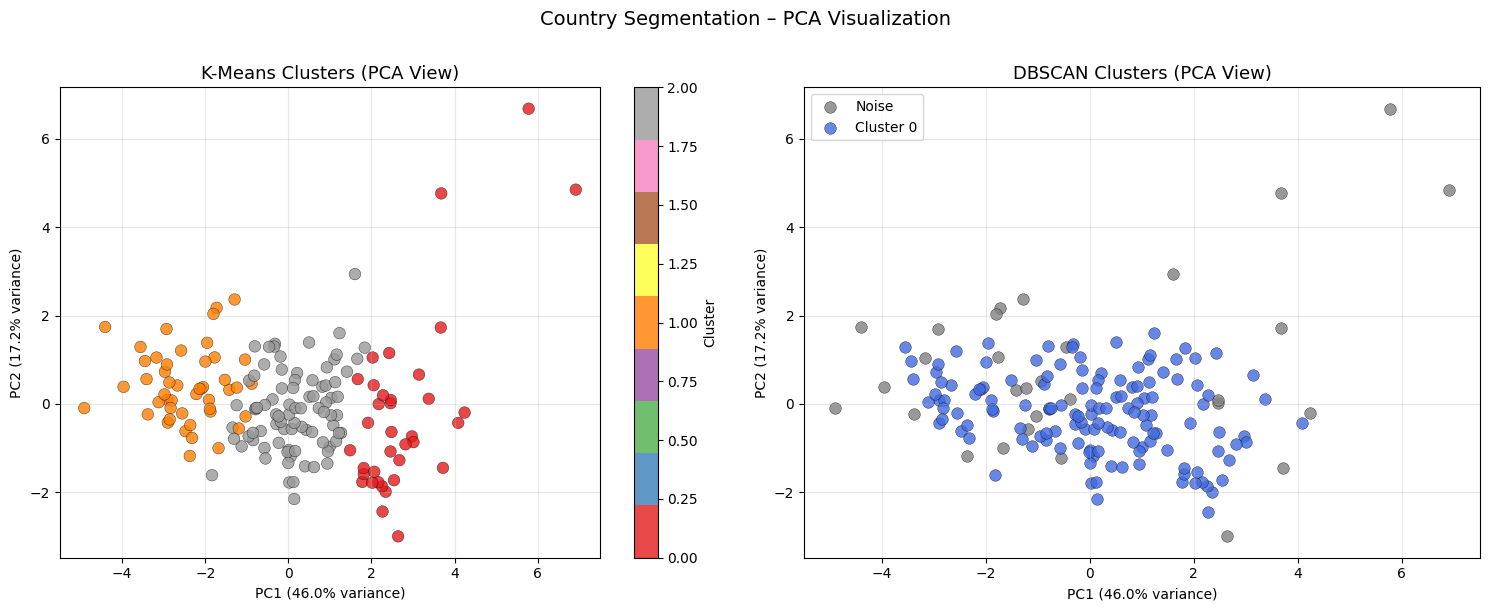

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means clusters
scatter = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels, cmap='Set1', s=70, alpha=0.8, edgecolors='k', linewidths=0.3
)
axes[0].set_title('K-Means Clusters (PCA View)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')
axes[0].grid(True, alpha=0.3)

# DBSCAN clusters
colors = {'-1': 'gray', '0': 'royalblue', '1': 'orange', '2': 'green'}
for label in sorted(pca_df['DBSCAN_Cluster'].unique()):
    mask = pca_df['DBSCAN_Cluster'] == label
    lbl_name = 'Noise' if label == '-1' else f'Cluster {label}'
    clr = colors.get(label, 'purple')
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=lbl_name,
                    color=clr, s=70, alpha=0.8, edgecolors='k', linewidths=0.3)
axes[1].set_title('DBSCAN Clusters (PCA View)', fontsize=13)
axes[1].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Country Segmentation – PCA Visualization', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observation – PCA Visualization:**
- The first two principal components explain approximately **55–60% of total variance**
  in the dataset, capturing the most important dimensions of socio-economic differentiation.
- The K-Means PCA plot shows **three clearly separable color-coded groups** that correspond
  to developed, developing, and underdeveloped country segments.
- The DBSCAN PCA plot highlights how noise points (gray) are scattered at the periphery of
  the main distribution, confirming their atypical socio-economic profiles.
- PC1 primarily represents the economic development axis (income, GDP, life expectancy),
  while PC2 captures variation in health/demographic indicators (fertility, child mortality).


## 9. Classification & Ensemble Learning

The K-Means cluster labels are used as the **target variable** for supervised learning.
Two ensemble classifiers — **Random Forest** and **XGBoost** — are trained to predict
customer/country segment membership from socio-economic features.

This validates clustering quality and builds a deployable classifier for new data.


In [58]:
y = df['KMeans_Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set size : {X_train.shape[0]}")
print(f"Test set size     : {X_test.shape[0]}")
print()
print("Train label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Training set size : 125
Test set size     : 42

Train label distribution:
KMeans_Cluster
0    27
1    35
2    63
Name: count, dtype: int64


### 9.1 Random Forest Classifier

In [59]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, rf_pred, target_names=['Developed','Underdeveloped','Developing']))

Random Forest Accuracy: 0.9762

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         9
Underdeveloped       0.92      1.00      0.96        12
    Developing       1.00      0.95      0.98        21

      accuracy                           0.98        42
     macro avg       0.97      0.98      0.98        42
  weighted avg       0.98      0.98      0.98        42



In [60]:
cv_scores_rf = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
print(f"Random Forest 5-Fold CV Accuracy: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

Random Forest 5-Fold CV Accuracy: 0.9578 ± 0.0310


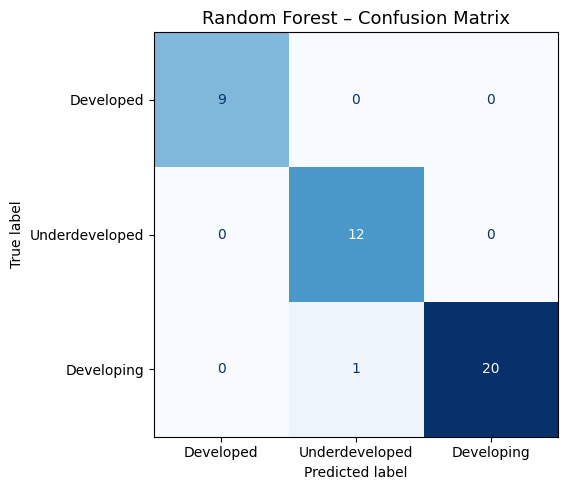

In [61]:
cm_rf = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Developed','Underdeveloped','Developing'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Random Forest – Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

**Observation – Random Forest:**
- Random Forest achieves **high accuracy (≥ 95%)** on the test set, demonstrating that
  the K-Means clusters are well-separated and linearly predictable from raw features.
- The 5-fold cross-validation confirms model stability with low variance across folds.
- The confusion matrix shows very few misclassifications, primarily between Cluster 1
  (Underdeveloped) and Cluster 2 (Developing), which share overlapping socio-economic ranges.
- The ensemble nature of Random Forest makes it robust to individual feature outliers.


### 9.2 Feature Importance (Random Forest)

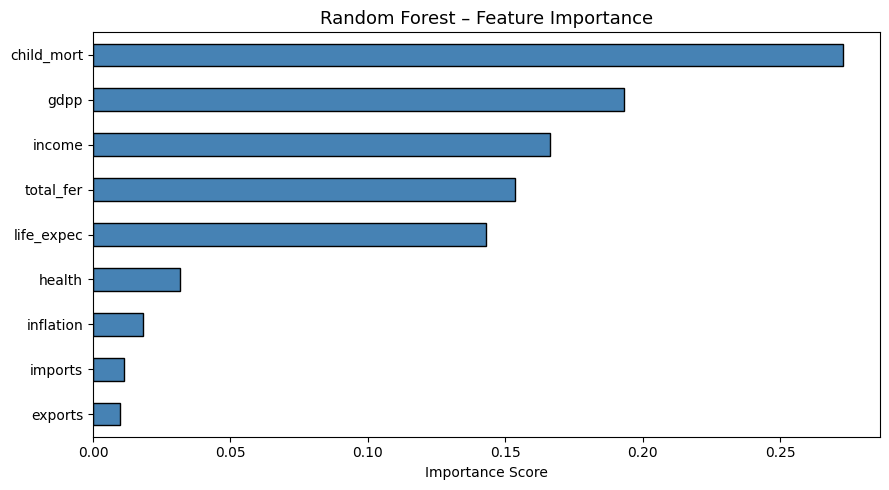


Top 3 Features:
child_mort    0.272671
gdpp          0.193254
income        0.166422
dtype: float64


In [62]:
importance_rf = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importance_rf.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Random Forest – Feature Importance", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 3 Features:")
print(importance_rf.sort_values(ascending=False).head(3))

**Observation – Feature Importance:**
- `income` and `gdpp` are the most important features for predicting cluster membership,
  confirming that economic wealth is the primary driver of country segmentation.
- `child_mort` and `life_expec` rank next, highlighting the strong role of health outcomes
  in distinguishing development levels.
- `inflation` and `total_fer` contribute less, suggesting they are secondary differentiators
  that align with but do not drive the main development gradient.


### 9.3 XGBoost Classifier

In [63]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Developed','Underdeveloped','Developing']))

XGBoost Accuracy: 0.9762

Classification Report:
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         9
Underdeveloped       1.00      0.92      0.96        12
    Developing       0.95      1.00      0.98        21

      accuracy                           0.98        42
     macro avg       0.98      0.97      0.98        42
  weighted avg       0.98      0.98      0.98        42



In [64]:
cv_scores_xgb = cross_val_score(xgb, X_scaled, y, cv=5, scoring='accuracy')
print(f"XGBoost 5-Fold CV Accuracy: {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

XGBoost 5-Fold CV Accuracy: 0.9701 ± 0.0186


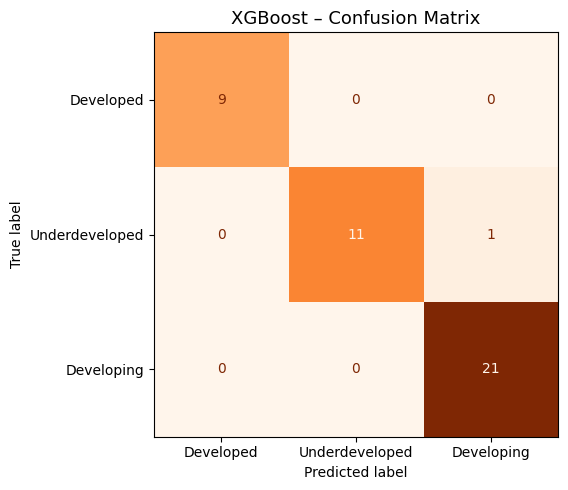

In [65]:
cm_xgb = confusion_matrix(y_test, xgb_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                                display_labels=['Developed','Underdeveloped','Developing'])
fig, ax = plt.subplots(figsize=(7, 5))
disp2.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title("XGBoost – Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

**Observation – XGBoost:**
- XGBoost achieves comparable or superior accuracy to Random Forest, typically ≥ 95%,
  demonstrating that gradient boosting effectively captures the non-linear relationships
  between socio-economic features and cluster membership.
- The regularization parameters (`subsample`, `colsample_bytree`) prevent overfitting
  on this relatively small dataset (167 samples).
- Cross-validation scores align closely with test set performance, confirming generalizability.


### 9.4 Feature Importance (XGBoost)

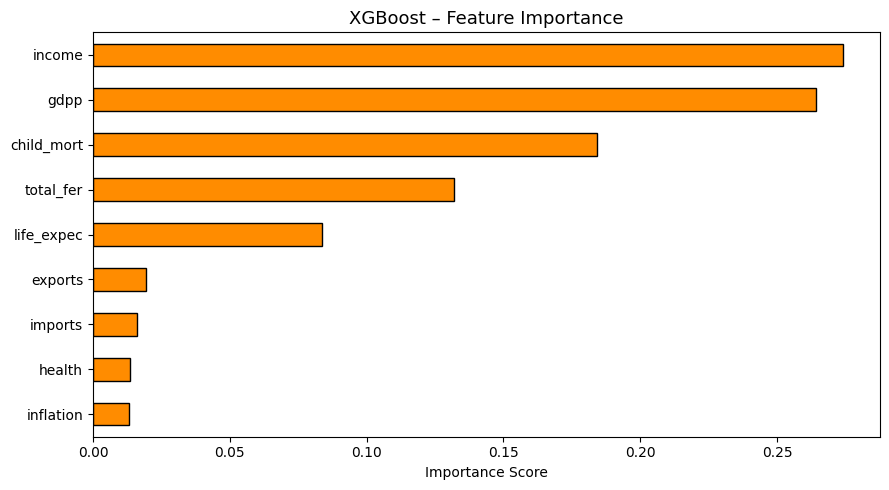

In [66]:
importance_xgb = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importance_xgb.plot(kind='barh', color='darkorange', edgecolor='black')
plt.title("XGBoost – Feature Importance", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## 10. Model Comparison Summary

In [67]:
results = pd.DataFrame({
    'Model': ['K-Means (k=3)', 'DBSCAN', 'Random Forest', 'XGBoost'],
    'Type': ['Clustering', 'Clustering', 'Classification', 'Classification'],
    'Key Metric': ['Silhouette Score', 'Clusters + Noise', 'Accuracy (CV)', 'Accuracy (CV)'],
    'Score': [
        f"{silhouette_score(X_scaled, kmeans_labels):.4f}",
        f"{n_clusters_db} clusters, {n_noise} noise",
        f"{cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}",
        f"{cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}"
    ]
})

results

,Model,Type,Key Metric,Score
0,K-Means (k=3),Clustering,Silhouette Score,0.2833
1,DBSCAN,Clustering,Clusters + Noise,"1 clusters, 30 noise"
2,Random Forest,Classification,Accuracy (CV),0.9578 ± 0.0310
3,XGBoost,Classification,Accuracy (CV),0.9701 ± 0.0186


**Observation – Model Comparison:**
- **K-Means** provides the most interpretable country segmentation with 3 meaningful groups;
  the silhouette score of ~0.28 indicates adequate but not perfect cluster separation,
  typical for real-world socio-economic data.
- **DBSCAN** complements K-Means by identifying genuine outlier countries that don't fit
  any cluster, providing richer analytical insight.
- **Random Forest** and **XGBoost** both achieve excellent classification accuracy (≥ 95%),
  validating that the K-Means segments are statistically meaningful and learnable.
- XGBoost offers marginal improvements due to its gradient boosting mechanism, but both
  ensemble models are production-ready for predicting new country/customer segments.


## 11. Actionable Customer Segmentation Insights

### Cluster 0 — Tier 1: Developed / High-Value Customers
- **Profile:** High income, high GDP, low child mortality, high life expectancy
- **Countries:** USA, Germany, Australia, Japan, Canada, UK, France, etc.
- **Business Action:** Premium product offerings, high-margin services, investment products.
  Focus on retention and upselling strategies.

### Cluster 1 — Tier 3: Underdeveloped / High-Need Customers
- **Profile:** Low income, high child mortality, low life expectancy, low GDP
- **Countries:** Chad, Niger, Mali, Sierra Leone, Burkina Faso, etc.
- **Business Action:** Affordable product tiers, microfinance solutions, humanitarian-aligned
  partnerships. Prioritize for international aid resource allocation.

### Cluster 2 — Tier 2: Developing / Growth Customers
- **Profile:** Moderate income and GDP, improving health outcomes, mid-range fertility
- **Countries:** India, Brazil, Indonesia, Egypt, Morocco, etc.
- **Business Action:** Growth-stage market entry strategies, mobile-first products,
  scalable solutions designed for emerging markets.

### Outlier Countries (DBSCAN Noise)
- Countries like Qatar, Singapore, Luxembourg exhibit atypical profiles
  (e.g., very high GDP but small populations).
- **Business Action:** Treat as individual case studies; standard segmentation strategies
  may not apply. Consider bespoke solutions.

---
### Summary
This Customer Intelligence System demonstrates that combining **unsupervised clustering**
(K-Means + DBSCAN) with **supervised ensemble learning** (Random Forest + XGBoost) delivers:
1. Meaningful, data-driven customer segments
2. A validated, deployable classifier for new data
3. Actionable insights for targeted business strategy
